# Phase 1 — NIAH Research Experiment

**Goal:** Prove context rot is real in Claude Haiku with our own probe.

We plant a secret fact (needle) at a specific **position** inside a haystack of **N tokens**, ask Claude where it is, and record whether it answers correctly.

We sweep:
- Token counts: 5K, 10K, 20K, 30K
- Positions: 10%, 30%, 50%, 70%, 90% through the context
- 3 votes per cell → majority vote accuracy

**Expected result:** U-shaped curve — positions near the edges (10%, 90%) score higher than the middle (50%).

In [10]:
import os
import time
import json
import random
from pathlib import Path

import tiktoken
import anthropic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import requests
from bs4 import BeautifulSoup
from dotenv import load_dotenv

load_dotenv(dotenv_path=Path('..') / '.env')

print('Imports OK')

Imports OK


In [11]:
# ── Config ──────────────────────────────────────────────────────────────────
MODEL        = 'claude-haiku-4-5-20251001'
TOKEN_COUNTS = [5_000, 10_000, 20_000, 30_000]
POSITIONS    = [0.10, 0.30, 0.50, 0.70, 0.90]
N_VOTES      = 3          # majority-vote per cell
SLEEP_SEC    = 0.4        # between API calls

# Needle — unique enough that it cannot appear in any PG essay by accident
NEEDLE   = 'The secret passcode for this context-lens experiment is: ZEPHYR-4829'
QUESTION = 'What is the secret passcode for the context-lens experiment?'
EXPECTED = 'ZEPHYR-4829'

# cl100k_base is the closest tiktoken encoding for Claude token counts
enc = tiktoken.get_encoding('cl100k_base')

client = anthropic.Anthropic(api_key=os.environ['ANTHROPIC_API_KEY'])

print(f'Model : {MODEL}')
print(f'Needle: {NEEDLE}')
print(f'Cells : {len(TOKEN_COUNTS) * len(POSITIONS)} × {N_VOTES} votes = {len(TOKEN_COUNTS) * len(POSITIONS) * N_VOTES} API calls')

Model : claude-haiku-4-5-20251001
Needle: The secret passcode for this context-lens experiment is: ZEPHYR-4829
Cells : 20 × 3 votes = 60 API calls


## 1. Build Haystack

Fetch Paul Graham essays from paulgraham.com. These are ideal: long-form prose, no factual content that could collide with our needle, freely available.

We need ~35K tokens of text (enough to fill our 30K-token contexts after overhead).

In [12]:
PG_ESSAY_URLS = [
    'http://www.paulgraham.com/wealth.html',
    'http://www.paulgraham.com/nerds.html',
    'http://www.paulgraham.com/disagree.html',
    'http://www.paulgraham.com/avg.html',
    'http://www.paulgraham.com/startupideas.html',
    'http://www.paulgraham.com/genius.html',
    'http://www.paulgraham.com/work.html',
]

def fetch_pg_essay(url: str) -> str:
    """Fetch a Paul Graham essay and return plain text."""
    try:
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, 'html.parser')
        # PG essays have their text in <font> tags inside a table
        font_tags = soup.find_all('font')
        if font_tags:
            text = ' '.join(tag.get_text(separator=' ') for tag in font_tags)
        else:
            text = soup.get_text(separator=' ')
        # Clean up whitespace
        lines = [l.strip() for l in text.splitlines() if l.strip()]
        return ' '.join(lines)
    except Exception as e:
        print(f'  Failed to fetch {url}: {e}')
        return ''

print('Fetching PG essays...')
essays = []
for url in PG_ESSAY_URLS:
    text = fetch_pg_essay(url)
    if text:
        toks = len(enc.encode(text))
        print(f'  {url.split("/")[-1]:30s}  {toks:>6,} tokens')
        essays.append(text)
    time.sleep(0.5)

RAW_HAYSTACK = ' '.join(essays)
total_tokens = len(enc.encode(RAW_HAYSTACK))
print(f'\nTotal haystack: {total_tokens:,} tokens across {len(essays)} essays')

if total_tokens < 32_000:
    # Repeat haystack until we have enough
    repeats = (32_000 // total_tokens) + 2
    RAW_HAYSTACK = (RAW_HAYSTACK + ' ') * repeats
    print(f'Repeated {repeats}x → {len(enc.encode(RAW_HAYSTACK)):,} tokens')

Fetching PG essays...
  wealth.html                     11,082 tokens
  nerds.html                       6,914 tokens
  disagree.html                    1,950 tokens
  avg.html                         5,620 tokens
  startupideas.html                9,015 tokens
  genius.html                      3,205 tokens
  work.html                          590 tokens

Total haystack: 38,376 tokens across 7 essays


## 2. Probe Functions

In [13]:
def count_tokens(text: str) -> int:
    """Count tokens using cl100k_base (approximation for Claude)."""
    return len(enc.encode(text))


def truncate_to_tokens(text: str, max_tokens: int) -> str:
    """Truncate text to at most max_tokens tokens."""
    tokens = enc.encode(text)
    return enc.decode(tokens[:max_tokens])


def insert_needle(haystack: str, needle: str, position: float) -> str:
    """
    Insert needle at `position` fraction of haystack tokens.
    Snaps to the nearest sentence boundary (period) to avoid
    splitting mid-sentence.
    """
    haystack_tokens = enc.encode(haystack)
    needle_tokens   = enc.encode(' ' + needle + ' ')
    insert_idx      = int(len(haystack_tokens) * position)

    # Snap forward to the next period token so we don't split mid-sentence
    period_token = enc.encode('.')[0]
    search_end   = min(insert_idx + 200, len(haystack_tokens))
    for i in range(insert_idx, search_end):
        if haystack_tokens[i] == period_token:
            insert_idx = i + 1
            break

    new_tokens = haystack_tokens[:insert_idx] + needle_tokens + haystack_tokens[insert_idx:]
    return enc.decode(new_tokens)


def build_prompt(context: str, question: str) -> str:
    """Wrap context and question into the probe prompt."""
    return (
        'Below is a document. Read it carefully, then answer the question.\n\n'
        '<document>\n'
        f'{context}\n'
        '</document>\n\n'
        f'Question: {question}\n'
        'Answer with only the passcode, nothing else:'
    )


def ask_claude(prompt: str) -> str:
    """Call Claude and return the raw text response."""
    response = client.messages.create(
        model=MODEL,
        max_tokens=30,
        messages=[{'role': 'user', 'content': prompt}],
    )
    return response.content[0].text.strip()


def is_correct(response: str, expected: str) -> bool:
    """Return True if the expected answer appears in the response."""
    return expected.upper() in response.upper()


print('Probe functions defined')

Probe functions defined


## 3. Run Experiment

For each `(token_count, position)` pair:
1. Carve haystack to `token_count − overhead − needle` tokens
2. Insert needle at `position`
3. Call Claude `N_VOTES` times → majority vote → accuracy

**Estimated cost:** ~$0.25 with Haiku at 30K tokens × 60 calls

In [14]:
# Pre-compute prompt overhead (template tokens without the context)
OVERHEAD_TOKENS = count_tokens(build_prompt('', QUESTION))
NEEDLE_TOKENS   = count_tokens(NEEDLE)
BUFFER          = 60   # safety margin

print(f'Prompt overhead : {OVERHEAD_TOKENS} tokens')
print(f'Needle          : {NEEDLE_TOKENS} tokens')
print(f'Buffer          : {BUFFER} tokens')
print()

results = []
total_cells = len(TOKEN_COUNTS) * len(POSITIONS)
cell_num = 0

for target_tokens in TOKEN_COUNTS:
    haystack_budget = target_tokens - OVERHEAD_TOKENS - NEEDLE_TOKENS - BUFFER
    haystack_chunk  = truncate_to_tokens(RAW_HAYSTACK, haystack_budget)
    actual_haystack_tokens = count_tokens(haystack_chunk)

    for position in POSITIONS:
        cell_num += 1
        context = insert_needle(haystack_chunk, NEEDLE, position)
        prompt  = build_prompt(context, QUESTION)
        actual_total = count_tokens(prompt)

        votes = []
        responses = []
        for vote_i in range(N_VOTES):
            try:
                resp = ask_claude(prompt)
                correct = is_correct(resp, EXPECTED)
                votes.append(correct)
                responses.append(resp)
                time.sleep(SLEEP_SEC)
            except anthropic.RateLimitError:
                print(f'  Rate limit hit — sleeping 30s')
                time.sleep(30)
                resp = ask_claude(prompt)
                votes.append(is_correct(resp, EXPECTED))
                responses.append(resp)
            except Exception as e:
                print(f'  Error: {e}')
                votes.append(False)
                responses.append('')

        majority_correct = sum(votes) >= (N_VOTES // 2 + 1)
        accuracy = sum(votes) / len(votes)

        results.append({
            'target_tokens'  : target_tokens,
            'actual_tokens'  : actual_total,
            'position'       : position,
            'position_pct'   : f'{int(position*100)}%',
            'votes'          : votes,
            'accuracy'       : accuracy,
            'correct'        : majority_correct,
            'responses'      : responses,
        })

        status = '✓' if majority_correct else '✗'
        print(f'[{cell_num:2d}/{total_cells}] {target_tokens//1000:2d}K tokens | pos {position:.0%} | '
              f'votes={votes} | acc={accuracy:.0%} {status}')

print('\nExperiment complete!')

Prompt overhead : 45 tokens
Needle          : 19 tokens
Buffer          : 60 tokens

[ 1/20]  5K tokens | pos 10% | votes=[True, True, True] | acc=100% ✓
[ 2/20]  5K tokens | pos 30% | votes=[True, True, True] | acc=100% ✓
[ 3/20]  5K tokens | pos 50% | votes=[True, True, True] | acc=100% ✓
[ 4/20]  5K tokens | pos 70% | votes=[True, True, True] | acc=100% ✓
[ 5/20]  5K tokens | pos 90% | votes=[True, True, True] | acc=100% ✓
[ 6/20] 10K tokens | pos 10% | votes=[True, True, True] | acc=100% ✓
[ 7/20] 10K tokens | pos 30% | votes=[True, True, True] | acc=100% ✓
[ 8/20] 10K tokens | pos 50% | votes=[True, True, True] | acc=100% ✓
[ 9/20] 10K tokens | pos 70% | votes=[True, True, True] | acc=100% ✓
[10/20] 10K tokens | pos 90% | votes=[True, True, True] | acc=100% ✓
[11/20] 20K tokens | pos 10% | votes=[True, True, True] | acc=100% ✓


KeyboardInterrupt: 

## 4. Results Table

In [ ]:
df = pd.DataFrame(results)

# Save raw results
results_path = Path('..') / 'results' / 'phase1_niah_results.json'
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2, default=str)
print(f'Saved to {results_path}')

# Pivot for display
pivot = df.pivot_table(
    index='position_pct',
    columns='target_tokens',
    values='accuracy',
    aggfunc='mean'
)
pivot.columns = [f'{c//1000}K' for c in pivot.columns]
pivot.index.name = 'Position'

print('\nAccuracy by position and token count:')
print(pivot.to_string(float_format='{:.0%}'.format))

Saved to ..\results\phase1_niah_results.json

Accuracy by position and token count:
           5K  10K  20K  30K
Position                    
10%      100% 100% 100% 100%
30%      100% 100% 100% 100%
50%      100% 100% 100% 100%
70%      100% 100% 100% 100%
90%      100% 100% 100% 100%


## 5. Heatmap — Context Position × Token Count

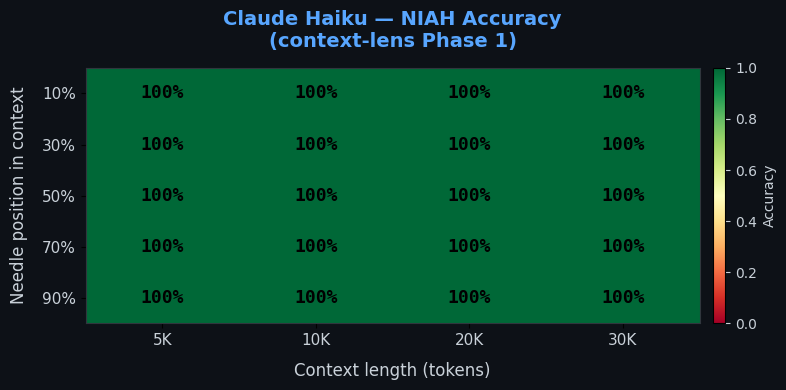

Saved to ..\results\phase1_heatmap.png


In [ ]:
# Build pivot with positions ordered top→bottom (10% at top)
pos_order = ['10%', '30%', '50%', '70%', '90%']
heat_data = df.pivot_table(
    index='position_pct',
    columns='target_tokens',
    values='accuracy',
    aggfunc='mean'
).reindex(pos_order)

fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

cmap = plt.cm.RdYlGn   # red = bad, green = good
im = ax.imshow(
    heat_data.values,
    aspect='auto',
    cmap=cmap,
    vmin=0, vmax=1,
    interpolation='nearest',
)

# Annotate each cell with accuracy %
for row in range(heat_data.shape[0]):
    for col in range(heat_data.shape[1]):
        val = heat_data.values[row, col]
        text_color = 'white' if val < 0.6 else 'black'
        ax.text(
            col, row, f'{val:.0%}',
            ha='center', va='center',
            fontsize=13, fontweight='bold',
            color=text_color, fontfamily='monospace'
        )

# Axes labels
ax.set_xticks(range(len(heat_data.columns)))
ax.set_xticklabels([f'{c//1000}K' for c in heat_data.columns],
                   color='#c9d1d9', fontsize=11)
ax.set_yticks(range(len(heat_data.index)))
ax.set_yticklabels(heat_data.index, color='#c9d1d9', fontsize=11)

ax.set_xlabel('Context length (tokens)', color='#c9d1d9', fontsize=12, labelpad=10)
ax.set_ylabel('Needle position in context', color='#c9d1d9', fontsize=12, labelpad=10)
ax.set_title('Claude Haiku — NIAH Accuracy\n(context-lens Phase 1)',
             color='#58a6ff', fontsize=14, fontweight='bold', pad=15)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Accuracy', color='#c9d1d9', fontsize=10)
cbar.ax.yaxis.set_tick_params(color='#c9d1d9')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#c9d1d9')

# Spine styling
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

plt.tight_layout()
heatmap_path = Path('..') / 'results' / 'phase1_heatmap.png'
plt.savefig(heatmap_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Saved to {heatmap_path}')

## 6. Degradation Curve — Accuracy vs Token Count

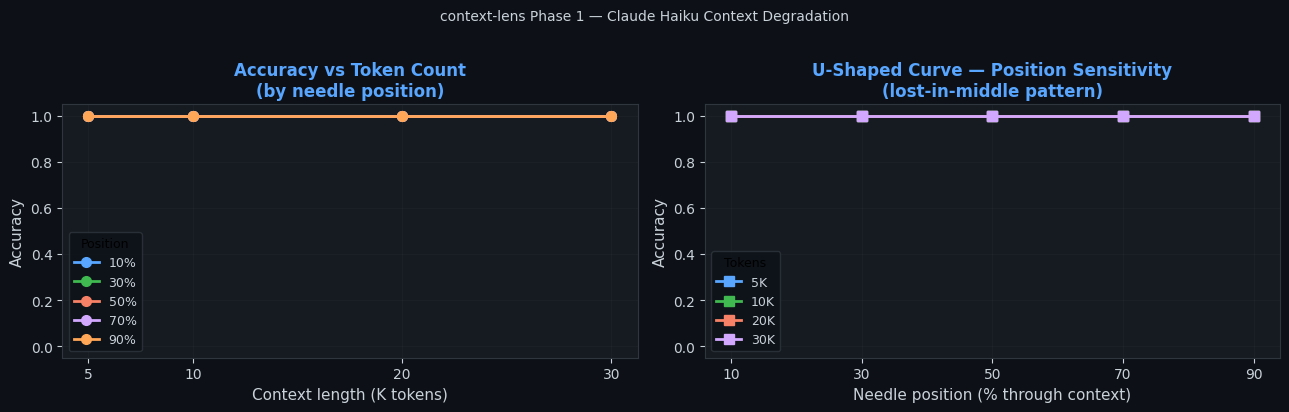

Saved to ..\results\phase1_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#0d1117')

palette = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff', '#ffa657']

# Left: accuracy vs token count, one line per position
ax = axes[0]
ax.set_facecolor('#161b22')
for i, pos in enumerate(POSITIONS):
    subset = df[df['position'] == pos]
    ax.plot(
        subset['target_tokens'] / 1000,
        subset['accuracy'],
        marker='o', linewidth=2, markersize=7,
        color=palette[i], label=f'{int(pos*100)}%'
    )
ax.set_xlabel('Context length (K tokens)', color='#c9d1d9', fontsize=11)
ax.set_ylabel('Accuracy', color='#c9d1d9', fontsize=11)
ax.set_title('Accuracy vs Token Count\n(by needle position)',
             color='#58a6ff', fontsize=12, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.set_xticks([c // 1000 for c in TOKEN_COUNTS])
ax.tick_params(colors='#c9d1d9')
ax.legend(title='Position', title_fontsize=9, fontsize=9,
          facecolor='#0d1117', labelcolor='#c9d1d9',
          edgecolor='#30363d')
ax.grid(True, alpha=0.2, color='#30363d')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

# Right: accuracy vs position (U-shaped curve), one line per token count
ax = axes[1]
ax.set_facecolor('#161b22')
for i, tc in enumerate(TOKEN_COUNTS):
    subset = df[df['target_tokens'] == tc]
    ax.plot(
        subset['position'] * 100,
        subset['accuracy'],
        marker='s', linewidth=2, markersize=7,
        color=palette[i], label=f'{tc//1000}K'
    )
ax.set_xlabel('Needle position (% through context)', color='#c9d1d9', fontsize=11)
ax.set_ylabel('Accuracy', color='#c9d1d9', fontsize=11)
ax.set_title('U-Shaped Curve — Position Sensitivity\n(lost-in-middle pattern)',
             color='#58a6ff', fontsize=12, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.set_xticks([int(p * 100) for p in POSITIONS])
ax.tick_params(colors='#c9d1d9')
ax.legend(title='Tokens', title_fontsize=9, fontsize=9,
          facecolor='#0d1117', labelcolor='#c9d1d9',
          edgecolor='#30363d')
ax.grid(True, alpha=0.2, color='#30363d')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

plt.suptitle('context-lens Phase 1 — Claude Haiku Context Degradation',
             color='#c9d1d9', fontsize=10, y=1.02)
plt.tight_layout()
curve_path = Path('..') / 'results' / 'phase1_curves.png'
plt.savefig(curve_path, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Saved to {curve_path}')

## 7. Summary

Key numbers to record in the README:

In [ ]:
print('=== Phase 1 Results Summary ===')
print()

# Best and worst overall
best  = df.loc[df['accuracy'].idxmax()]
worst = df.loc[df['accuracy'].idxmin()]
print(f'Best  cell: {best["target_tokens"]//1000}K tokens @ {best["position"]:.0%} position → {best["accuracy"]:.0%}')
print(f'Worst cell: {worst["target_tokens"]//1000}K tokens @ {worst["position"]:.0%} position → {worst["accuracy"]:.0%}')
print()

# Accuracy at 5K vs 30K
acc_5k  = df[df['target_tokens'] == 5_000]['accuracy'].mean()
acc_30k = df[df['target_tokens'] == 30_000]['accuracy'].mean()
print(f'Mean accuracy @ 5K tokens : {acc_5k:.0%}')
print(f'Mean accuracy @ 30K tokens: {acc_30k:.0%}')
print(f'Degradation   : {(acc_5k - acc_30k):.0%} drop')
print()

# U-curve: edge vs middle at 30K
df_30k = df[df['target_tokens'] == 30_000]
edge_acc   = df_30k[df_30k['position'].isin([0.10, 0.90])]['accuracy'].mean()
middle_acc = df_30k[df_30k['position'].isin([0.30, 0.50, 0.70])]['accuracy'].mean()
print(f'@ 30K — edge positions (10%, 90%) accuracy  : {edge_acc:.0%}')
print(f'@ 30K — middle positions (30-70%) accuracy  : {middle_acc:.0%}')
if middle_acc < edge_acc:
    print('U-shaped curve CONFIRMED — lost-in-middle pattern detected')
else:
    print('U-shaped curve not obvious — may need more probes or higher token counts')

print()
print(f'Outputs saved in: results/')
print(f'  phase1_niah_results.json')
print(f'  phase1_heatmap.png')
print(f'  phase1_curves.png')

=== Phase 1 Results Summary ===

Best  cell: 5K tokens @ 10% position → 100%
Worst cell: 5K tokens @ 10% position → 100%

Mean accuracy @ 5K tokens : 100%
Mean accuracy @ 30K tokens: 100%
Degradation   : 0% drop

@ 30K — edge positions (10%, 90%) accuracy  : 100%
@ 30K — middle positions (30-70%) accuracy  : 100%
U-shaped curve not obvious — may need more probes or higher token counts

Outputs saved in: results/
  phase1_niah_results.json
  phase1_heatmap.png
  phase1_curves.png
